In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

In [2]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from config import *
from fe import build_features, fix_nan
from train import (
    load_data, prepare_splits, check_nan_after_fix,
    run_cv, retrain_and_predict, plot_forecast,
    explain_model, save_submission
)

In [3]:
 # 1. Load data
sales, promotions, web, orders = load_data()

Data loaded!
  Train: 2012-07-04 -> 2022-12-31
  Test : 2023-01-01 -> 2024-07-01


In [4]:
# 2. Feature Engineering
print('── Feature Engineering ──')
full = build_features(sales, promotions, web, orders, TEST_START, TEST_END)

── Feature Engineering ──
Full timeline: 2012-07-04 -> 2024-07-01
Train rows: 3,833
Test  rows: 548
- Calendar features: OK!
  Revenue_lag728: 0.0% NaN trong test period
  Revenue_lag2y: 0.0% NaN trong test period
  Revenue_roll7_lag2y: 0.0% NaN trong test period
- Lag features: OK!
- Promotion features: OK!
- Web traffic features: OK!
  Web traffic coverage trong test period: 100.0%
- Orders features: OK!
- Structural period features: OK! 
- Combined features: OK!


In [5]:
# 3. Split
print('── Prepare Splits ──')
train_df, test_df, X_train, X_test, y_train_rev, y_train_cogs, feature_cols = prepare_splits(full)

── Prepare Splits ──
X_train: (2740, 80)
X_test : (548, 80)
Features: 80

Features có NaN > 5% trong train:
has_min_order    0.528102
dtype: float64


In [6]:
X_train, X_test = fix_nan(X_train, X_test)

- NaN fix: OK!


In [7]:
check_nan_after_fix(X_train, X_test)

NaN > 5% sau khi fix:
Chỉ còn lag Revenue/COGS đầu chuỗi — Moddel tự xử lý


In [8]:
# 4. CV setup
tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS, gap=CV_GAP, test_size=CV_TEST_SIZE)

print('Kiểm tra các fold:')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    d_tr  = train_df['Date'].iloc[tr_idx]
    d_val = train_df['Date'].iloc[val_idx]
    print(f'  Fold {fold+1}: train {d_tr.min().date()}->{d_tr.max().date()} '
          f'| val {d_val.min().date()}->{d_val.max().date()} '
          f'({len(val_idx)} ngày)')

Kiểm tra các fold:
  Fold 1: train 2015-07-04->2017-12-04 | val 2018-01-04->2019-01-02 (365 ngày)
  Fold 2: train 2015-07-04->2018-12-03 | val 2019-01-03->2020-01-02 (365 ngày)
  Fold 3: train 2015-07-04->2019-12-03 | val 2020-01-03->2021-01-01 (365 ngày)
  Fold 4: train 2015-07-04->2020-12-02 | val 2021-01-02->2022-01-01 (365 ngày)
  Fold 5: train 2015-07-04->2021-12-02 | val 2022-01-02->2022-12-31 (365 ngày)


In [9]:
# 5. LightGBM CV
print('\n' + '=' * 65)
print('LightGBM — Revenue (log1p target)')
print('=' * 65)
lgb_rev  = LGBMRegressor(**LGB_PARAMS)
cv_rev_lgb, _ = run_cv(clone(lgb_rev), X_train, y_train_rev, train_df['Date'], tscv, 'Revenue')

print('\n' + '=' * 65)
print('LightGBM — COGS (log1p target)')
print('=' * 65)
lgb_cogs = LGBMRegressor(**LGB_PARAMS)
cv_cogs_lgb, _ = run_cv(clone(lgb_cogs), X_train, y_train_cogs, train_df['Date'], tscv, 'COGS')


LightGBM — Revenue (log1p target)
  [Revenue] Fold 1 [2018-01-04->2019-01-02]: MAE=1,142,202  RMSE=1,588,941  R2=0.749
  Mean Pred: 5,544,611, Mean True: 5,076,411
  [Revenue] Fold 2 [2019-01-03->2020-01-02]: MAE=1,196,468  RMSE=1,659,346  R2=-0.019
  Mean Pred: 4,157,978, Mean True: 3,111,484
  [Revenue] Fold 3 [2020-01-03->2021-01-01]: MAE=643,345  RMSE=843,805  R2=0.733
  Mean Pred: 3,036,852, Mean True: 2,887,362
  [Revenue] Fold 4 [2021-01-02->2022-01-01]: MAE=667,322  RMSE=980,337  R2=0.643
  Mean Pred: 2,459,095, Mean True: 2,861,421
  [Revenue] Fold 5 [2022-01-02->2022-12-31]: MAE=674,705  RMSE=955,874  R2=0.676
  Mean Pred: 2,800,424, Mean True: 3,213,216
  ─────────────────────────────────────────────────────────────────
  Mean: MAE=864,808  RMSE=1,205,661  R2=0.556

LightGBM — COGS (log1p target)
  [COGS] Fold 1 [2018-01-04->2019-01-02]: MAE=993,631  RMSE=1,340,799  R2=0.733
  Mean Pred: 4,760,149, Mean True: 4,229,285
  [COGS] Fold 2 [2019-01-03->2020-01-02]: MAE=1,004,856

In [10]:
# 6. XGBoost CV
print('\n' + '=' * 65)
print('XGBoost — Revenue (log1p target)')
print('=' * 65)
xgb_rev  = XGBRegressor(**XGB_PARAMS)
cv_rev, _ = run_cv(clone(xgb_rev), X_train, y_train_rev, train_df['Date'], tscv, 'Revenue')

print('\n' + '=' * 65)
print('XGBoost — COGS (log1p target)')
print('=' * 65)
xgb_cogs = XGBRegressor(**XGB_PARAMS)
cv_cogs, _ = run_cv(clone(xgb_cogs), X_train, y_train_cogs, train_df['Date'], tscv, 'COGS')


XGBoost — Revenue (log1p target)
  [Revenue] Fold 1 [2018-01-04->2019-01-02]: MAE=1,098,409  RMSE=1,545,821  R2=0.763
  Mean Pred: 5,389,276, Mean True: 5,076,411
  [Revenue] Fold 2 [2019-01-03->2020-01-02]: MAE=858,935  RMSE=1,137,236  R2=0.521
  Mean Pred: 3,730,345, Mean True: 3,111,484
  [Revenue] Fold 3 [2020-01-03->2021-01-01]: MAE=642,318  RMSE=859,207  R2=0.723
  Mean Pred: 3,017,934, Mean True: 2,887,362
  [Revenue] Fold 4 [2021-01-02->2022-01-01]: MAE=629,126  RMSE=895,429  R2=0.702
  Mean Pred: 2,592,254, Mean True: 2,861,421
  [Revenue] Fold 5 [2022-01-02->2022-12-31]: MAE=675,097  RMSE=965,094  R2=0.670
  Mean Pred: 2,834,789, Mean True: 3,213,216
  ─────────────────────────────────────────────────────────────────
  Mean: MAE=780,777  RMSE=1,080,557  R2=0.676

XGBoost — COGS (log1p target)
  [COGS] Fold 1 [2018-01-04->2019-01-02]: MAE=990,477  RMSE=1,306,630  R2=0.747
  Mean Pred: 4,723,821, Mean True: 4,229,285
  [COGS] Fold 2 [2019-01-03->2020-01-02]: MAE=831,268  RMSE=

In [11]:
# 7. Retrain + Predict (dùng XGBoost)
print('── Retrain & Predict ──')
revenue_pred, cogs_pred = retrain_and_predict(
    xgb_rev, xgb_cogs,
    X_train, y_train_rev, y_train_cogs,
    X_test, train_df
)

── Retrain & Predict ──
Retrain on full train: OK!

Sanity check (30d đầu prediction vs 60d cuối train):
  Revenue: train=1,693,831 | pred=2,909,400 (ratio=1.72)
  COGS   : train=1,634,717 | pred=2,540,524 (ratio=1.55)


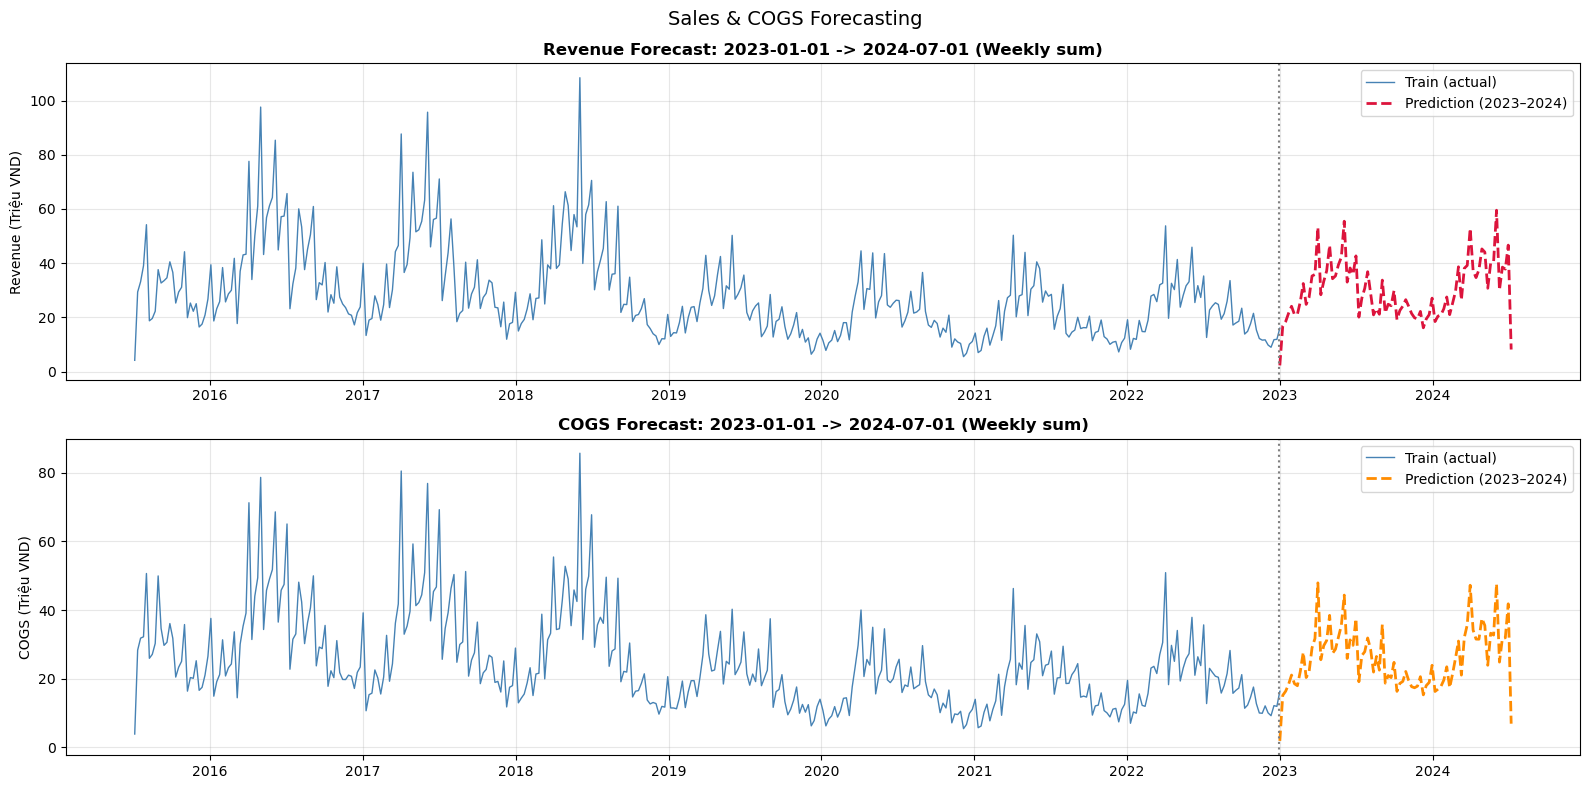

In [12]:
# 8. Plot forecast
plot_forecast(train_df, test_df, revenue_pred, cogs_pred)

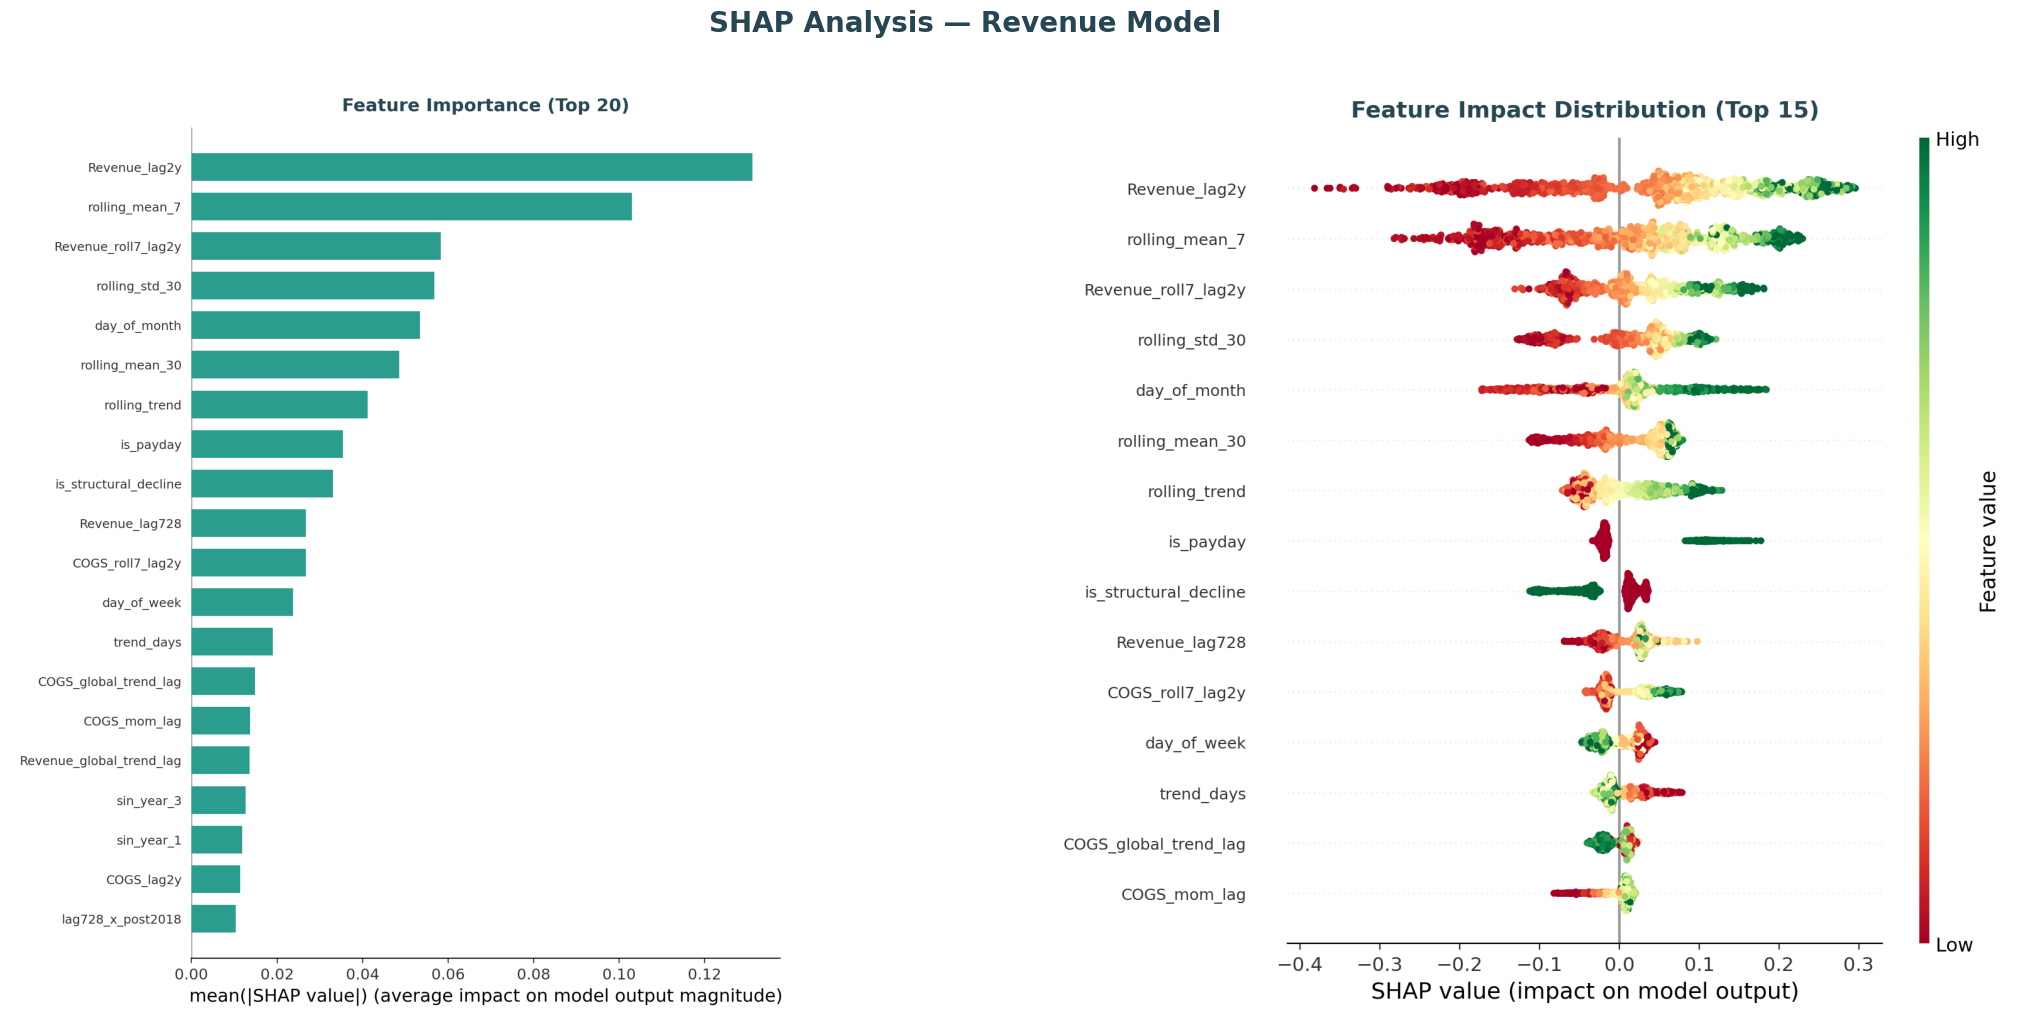

Saved: shap_revenue.png

Top 10 features quan trọng nhất (Revenue):
              feature  shap_importance
        Revenue_lag2y         0.131148
       rolling_mean_7         0.102974
  Revenue_roll7_lag2y         0.058232
       rolling_std_30         0.056826
         day_of_month         0.053396
      rolling_mean_30         0.048620
        rolling_trend         0.041159
            is_payday         0.035458
is_structural_decline         0.033116
       Revenue_lag728         0.026789


In [13]:
# 9. SHAP
importance_features = explain_model(xgb_rev, X_train)

In [14]:
# 10. CV Summary
# CV score
print('='*65)
print('CROSS-VALIDATION SUMMARY (TimeSeriesSplit, 5 folds, gap=30d)')
print('='*65)
print('\nRevenue:')
print(cv_rev.to_string(index=False))
print(f'  Mean MAE : {cv_rev.MAE.mean():,.0f}')
print(f'  Mean RMSE: {cv_rev.RMSE.mean():,.0f}')
print(f'  Mean R2  : {cv_rev.R2.mean():.4f}')

print('\nCOGS:')
print(cv_cogs.to_string(index=False))
print(f'  Mean MAE : {cv_cogs.MAE.mean():,.0f}')
print(f'  Mean RMSE: {cv_cogs.RMSE.mean():,.0f}')
print(f'  Mean R2  : {cv_cogs.R2.mean():.4f}')

CROSS-VALIDATION SUMMARY (TimeSeriesSplit, 5 folds, gap=30d)

Revenue:
 fold          MAE         RMSE       R2
    1 1.098409e+06 1.545821e+06 0.762517
    2 8.589347e+05 1.137236e+06 0.521311
    3 6.423177e+05 8.592068e+05 0.722950
    4 6.291263e+05 8.954287e+05 0.702043
    5 6.750973e+05 9.650943e+05 0.670051
  Mean MAE : 780,777
  Mean RMSE: 1,080,557
  Mean R2  : 0.6758

COGS:
 fold           MAE         RMSE       R2
    1 990477.069096 1.306630e+06 0.746815
    2 831267.737438 1.097966e+06 0.419549
    3 587659.389384 7.602518e+05 0.688785
    4 678778.574144 9.677464e+05 0.544009
    5 594650.852781 8.384597e+05 0.671471
  Mean MAE : 736,567
  Mean RMSE: 994,211
  Mean R2  : 0.6141


In [15]:
# 11. Save
save_submission(test_df, revenue_pred, cogs_pred)


Submission preview:
      Date    Revenue        COGS
2023-01-01 2276593.50 1880036.375
2023-01-02 2661155.75 2325781.000
2023-01-03 2561032.25 2232981.750
2023-01-04 2178589.50 1972758.125
2023-01-05 2273423.75 2035842.125
2023-01-06 2218968.75 2107927.750
2023-01-07 2312945.25 2169049.000
2023-01-08 2631399.25 2301058.000
2023-01-09 2879243.00 2478653.750
2023-01-10 2755863.25 2366127.000
Total rows     : 548
Revenue range  : [1992840, 10874725]
COGS range     : [1880036, 9022792]
Negative Rev   : 0
Negative COGS  : 0

Saved: submission.csv
